# Adiabatic Cooling Distortion

Electrons cool adiabatically faster than photons ($T_e \propto (1+z)^2$ vs $T_\gamma \propto (1+z)$), so Compton scattering continuously tries to equilibrate them by extracting energy from the photon field. This produces a small negative spectral distortion even without any external energy injection.

The cooling rate enters the solver as $\Lambda = H \cdot t_C \cdot \frac{3}{2} \frac{\alpha_h}{4\tilde{\rho}_\gamma}$, where $\alpha_h$ accounts for all baryonic species (electrons, H, He).

Here we run the PDE solver with **zero injection** to isolate this effect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spectroxide
from spectroxide import run_sweep, solve, strip_gbb, apply_style, C, SINGLE_COL
from spectroxide.cosmotherm import load_di_file, di_to_delta_n

apply_style()

## Run PDE with zero injection

Use a single-burst with $\Delta\rho/\rho = 0$ so the only source of distortion is adiabatic cooling of baryons. We evolve from $z = 3 \times 10^6$ down to $z = 500$.

Uses Planck 2015 cosmology to match the CosmoTherm `DI_cooling.dat` reference data.

In [ ]:
# Planck 2015 cosmology (matches DI_cooling.dat header)
cosmo_p15 = spectroxide.Cosmology.planck2015().to_dict()

# Zero injection: adiabatic cooling only
result = solve(
    injection={"type": "single_burst", "z_h": 1e5},
    delta_rho=0,
    z_start=3e6,
    z_end=10,
    cosmo=cosmo_p15,
    n_points=4000,
    number_conserving=True,
)

x = result.x
dn = result.delta_n

print(f"mu  = {result.mu:.4e}")
print(f"y   = {result.y:.4e}")
print(f"DT/T= {result.accumulated_delta_t:.4e}")
print(f"rho_e = {result.rho_e:.8f}")

## Comparison with CosmoTherm

Load `DI_cooling.dat` from Chluba (2016). Note: the file stores $-\Delta I$ (sign-flipped), so we negate on load.

In [4]:
# Load CosmoTherm reference (stores -ΔI, so negate)
ct_nu_ghz, ct_di_jy = load_di_file(name="DI_cooling.dat")
ct_di_jy = -ct_di_jy
ct_x, ct_dn = di_to_delta_n(ct_nu_ghz, ct_di_jy)

# Strip G_bb from both
dn_stripped, _ = strip_gbb(x, dn)
ct_dn_stripped, _ = strip_gbb(ct_x, ct_dn)

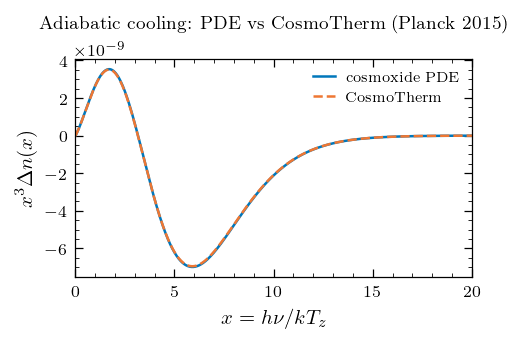

In [5]:
fig, ax = plt.subplots(figsize=(SINGLE_COL, SINGLE_COL * 0.7))

ax.plot(x, x**3 * dn_stripped, color=C["blue"], label="spectroxide PDE")
ax.plot(ct_x, ct_x**3 * ct_dn_stripped, color=C["orange"], ls="--", label="CosmoTherm")
ax.set_xlabel(r"$x = h\nu / k T_z$")
ax.set_ylabel(r"$x^3 \Delta n(x)$")
ax.set_xlim(0, 20)
ax.legend()
ax.set_title("Adiabatic cooling: PDE vs CosmoTherm (Planck 2015)")
fig.tight_layout()
plt.show()

## Electron temperature from the PDE solver

Extract $\rho_e = T_e / T_\gamma$ at each stopping redshift by running the solver repeatedly. Focus on $z = 10$–$10^4$ where Compton decoupling makes $T_e$ deviate from $T_\gamma$.

In [ ]:
z_stops = np.logspace(1, 4, 20)[::-1]  # z = 1e4 down to 10

rho_e_vals = []
for z_e in z_stops:
    res = solve(
        injection={"type": "single_burst", "z_h": 1e5},
        delta_rho=0,
        z_start=3e6,
        z_end=z_e,
        cosmo=cosmo_p15,
    )
    rho_e_vals.append(res.rho_e)
    print(f"z_end = {z_e:8.1f}: rho_e = {res.rho_e:.8f}")

z_stops = np.array(z_stops)
rho_e_vals = np.array(rho_e_vals)

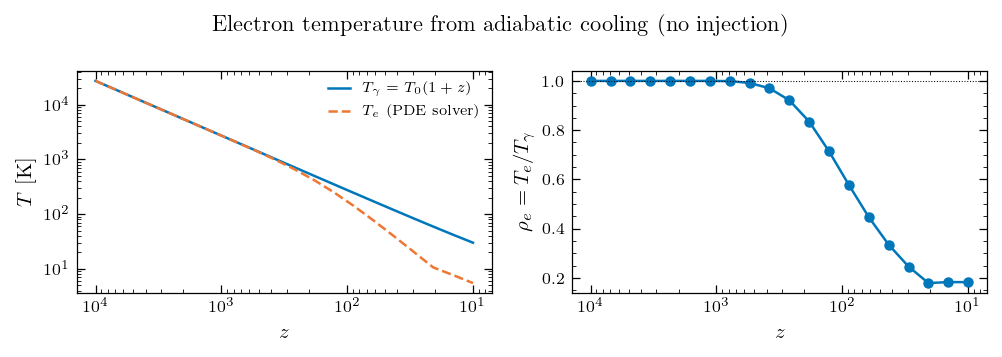

In [8]:
T_cmb0 = 2.726  # K
T_gamma = T_cmb0 * (1 + z_stops)
T_e = rho_e_vals * T_gamma

fig, axes = plt.subplots(1, 2, figsize=(SINGLE_COL * 2, SINGLE_COL * 0.7))

# Left: T_e and T_gamma vs z
ax = axes[0]
ax.plot(z_stops, T_gamma, color=C["blue"], label=r"$T_\gamma = T_0(1+z)$")
ax.plot(z_stops, T_e, color=C["orange"], ls="--", label=r"$T_e$ (PDE solver)")
ax.set_xlabel("$z$")
ax.set_ylabel("$T$ [K]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.invert_xaxis()

# Right: rho_e = T_e / T_gamma
ax = axes[1]
ax.plot(z_stops, rho_e_vals, "o-", color=C["blue"], ms=4)
ax.set_xlabel("$z$")
ax.set_ylabel(r"$\rho_e = T_e / T_\gamma$")
ax.set_xscale("log")
ax.axhline(1, color="k", ls=":", lw=0.5)
ax.invert_xaxis()

fig.suptitle("Electron temperature from adiabatic cooling (no injection)")
fig.tight_layout()
plt.show()